# Encoder Fine-Tuning vs. Decoder Zero-Shot Prompting


This project explores the practical trade-offs between two dominant Transformer architectures in natural language processing (NLP) using a sentiment analysis task.

Instead of relying on a single paradigm, this notebook demonstrates how to approach the same problem from two completely different angles:

1.  **The traditional understanding approach (Encoder-only)**: Fine-tuning a pre-trained **RoBERTa** model specifically for binary classification.
2.  **The modern generative approach (Decoder-only)**: Using a lightweight LLM (**Qwen 2.5 - 1.5B**) to classify text purely through zero-shot instruction prompting.

**Key Objectives:**
* Demonstrate end-to-end fine-tuning of an encoder model using PyTorch and HuggingFace.
* Implement prompt engineering and batched text generation for a decoder model.
* Compare the models based on accuracy, data requirements, and computational footprint.


In [10]:
import os
import time
import random
import warnings
import gc

import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)
from sklearn.metrics import accuracy_score, classification_report

# Filter warnings for cleaner output
warnings.filterwarnings("once")

# Set random seeds for reproducibility
SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

# Detect hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware in use: {device}")

# Environment variables to optimize Colab performance
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

Hardware in use: cuda


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **1. Data Ingestion**
We utilize the classic IMDB movie review dataset. To ensure rapid experimentation and fair comparison, we will sample a balanced subset of 5,000 training examples and 1,000 test examples. Both models will be evaluated against the exact same test subset.

In [11]:
print("Fetching IMDB dataset...")
imdb = load_dataset("stanfordnlp/imdb")

# Shuffle and subset the data
train_data = imdb["train"].shuffle(seed=SEED).select(range(5000))
test_data = imdb["test"].shuffle(seed=SEED).select(range(1000))

print(f"Data ready! Training samples: {len(train_data)}, Test samples: {len(test_data)}")

# Verify label distribution to ensure balance
labels = np.array(train_data["label"])
print(f"Training distribution -> Negative: {np.sum(labels == 0)}, Positive: {np.sum(labels == 1)}")

Fetching IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1856: DeprecationWarning: hf_xet.download_files() is deprecated. Use XetSession().new_file_download_group().start_download_file() instead.
  xet_get(
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x78ada6bcf460>


...

sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x78ada6bcfaf0>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x78ada6bcfe70>


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Data ready! Training samples: 5000, Test samples: 1000
Training distribution -> Negative: 2477, Positive: 2523


## **2. The Encoder Approach: Fine-tuning RoBERTa**

**RoBERTa (Robustly Optimized BERT Pretraining Approach)** is an encoder-only model. It excels at understanding context bidirectionally.

In this phase, we take the pre-trained `roberta-base` representations, attach a randomly initialized classification head, and update the weights using our labeled training data.,

In [12]:
# Initialize RoBERTa
encoder_name = "roberta-base"
encoder_tokenizer = AutoTokenizer.from_pretrained(encoder_name)
encoder_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_name,
    num_labels=2,
).to(device)

# Freeze the base model to train only the classification head for efficiency
for param in encoder_model.roberta.parameters():
    param.requires_grad = False

print(f"RoBERTa parameters: {encoder_model.num_parameters():,}")

# Tokenization pipeline
def tokenize_encoder(batch):
    return encoder_tokenizer(batch["text"], truncation=True, max_length=512)

encoder_train_ds = train_data.map(tokenize_encoder, batched=True, remove_columns=["text"]).rename_column("label", "labels")
encoder_test_ds = test_data.map(tokenize_encoder, batched=True, remove_columns=["text"]).rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=encoder_tokenizer)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa parameters: 124,647,170


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## TRAINING

In [13]:
# Define training hyperparameters
training_args = TrainingArguments(
    output_dir="./roberta-sentiment",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=[],
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

trainer = Trainer(
    model=encoder_model,
    args=training_args,
    train_dataset=encoder_train_ds,
    eval_dataset=encoder_test_ds,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

print("Initiating RoBERTa fine-tuning...")
trainer.train()

Initiating RoBERTa fine-tuning...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.667434,0.668391,0.804000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TrainOutput(global_step=625, training_loss=0.6801717712402344, metrics={'train_runtime': 179.3151, 'train_samples_per_second': 27.884, 'train_steps_per_second': 3.485, 'total_flos': 1231396739076960.0, 'train_loss': 0.6801717712402344, 'epoch': 1.0})

Evaluating and cleaning memory

In [14]:
# Evaluate the encoder
encoder_results = trainer.evaluate()
print(f"RoBERTa Test Accuracy: {encoder_results['eval_accuracy']:.4f}")

# Cache predictions for final comparison
encoder_predictions = np.argmax(trainer.predict(encoder_test_ds).predictions, axis=1)
true_labels = np.array(encoder_test_ds["labels"])

print("\nRoBERTa Classification Report:")
print(classification_report(true_labels, encoder_predictions, target_names=["Negative", "Positive"]))

# CRITICAL: Free up VRAM before loading the LLM
del trainer, encoder_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("GPU memory cleared for the next model.")

Training Loss,Validation Loss,Epoch,Accuracy
0.667434,0.668391,1,0.804000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


RoBERTa Test Accuracy: 0.8040


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



RoBERTa Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82       515
    Positive       0.83      0.75      0.79       485

    accuracy                           0.80      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.81      0.80      0.80      1000

GPU memory cleared for the next model.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **3. The Decoder Approach: Zero-Shot Prompting with Qwen 2.5**

Here, we shift paradigms. Instead of updating model weights, we rely on the emergent instruction-following capabilities of an autoregressive LLM.

We will use **`Qwen/Qwen2.5-1.5B-Instruct`**. It's a modern, highly capable lightweight decoder. Because this is a generative model, it requires **left-padding** when generating in batches so that the newly generated tokens naturally follow the prompt.

In [15]:
decoder_name = "Qwen/Qwen2.5-1.5B-Instruct"

decoder_tokenizer = AutoTokenizer.from_pretrained(decoder_name)
# Generative models require left-padding for batched inference
decoder_tokenizer.padding_side = "left"
if decoder_tokenizer.pad_token is None:
    decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

decoder_model = AutoModelForCausalLM.from_pretrained(
    decoder_name,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"Qwen 2.5 parameters: {decoder_model.num_parameters():,}")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1856: DeprecationWarning: hf_xet.download_files() is deprecated. Use XetSession().new_file_download_group().start_download_file() instead.
  xet_get(
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x78ad55f54670>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x78ada6bcfaf0>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x78ada6bcf3f0>


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen 2.5 parameters: 1,543,714,304


In [16]:
import pandas as pd
from collections import Counter

def zero_shot_classification_with_logging(texts, model, tokenizer, batch_size=8):
    """
    Runs zero-shot classification while logging the exact raw strings generated by the LLM
    to analyze how well it followed the 'exactly one word' instruction.
    """
    predictions = []
    raw_outputs = [] # Store the exact text generated by the model
    start_time = time.time()
    total = len(texts)

    print(f"🚀 Running zero-shot inference on {total} samples...")

    for i in range(0, total, batch_size):
        batch_texts = texts[i:i + batch_size]
        prompts = []

        # Construct chat templates
        for text in batch_texts:
            messages = [
                {"role": "system", "content": "You are an expert NLP sentiment analyzer."},
                {"role": "user", "content": f'Analyze the sentiment of this review. Respond with exactly one word: either "positive" or "negative".\n\nReview: "{text[:512]}"'}
            ]
            prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1024,
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=3, # We only need one word
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )

        input_len = inputs["input_ids"].shape[1]
        for j, output in enumerate(outputs):
            # Decode only the newly generated tokens
            response = tokenizer.decode(output[input_len:], skip_special_tokens=True).strip().lower()
            raw_outputs.append(response)

            # Parsing logic
            if "positive" in response:
                predictions.append(1)
            elif "negative" in response:
                predictions.append(0)
            else:
                predictions.append(0) # Default fallback

            # Print a live peek into the processing for the first batch
            if i == 0 and j < 3:
                print(f"\n🔍 [Live Peek - Sample {j+1}]")
                print(f"   Input text (truncated): '{batch_texts[j][:80]}...'")
                print(f"   RAW Output from Qwen:   '{response}'")
                print(f"   Parsed Final Label:     {'Positive (1)' if predictions[-1] == 1 else 'Negative (0)'}")

        if (i + batch_size) % 200 == 0 or (i + batch_size) >= total:
            print(f"📊 Processed {min(i + batch_size, total)}/{total}")

    print(f"\n✅ Inference complete in {time.time() - start_time:.1f} seconds.")
    return np.array(predictions), raw_outputs

# Evaluate on the exact same test set
test_texts = test_data["text"]
decoder_predictions, raw_responses = zero_shot_classification_with_logging(test_texts, decoder_model, decoder_tokenizer)

decoder_accuracy = accuracy_score(true_labels, decoder_predictions)
print(f"\n🎯 Qwen 2.5 Zero-Shot Accuracy: {decoder_accuracy:.4f}")

🚀 Running zero-shot inference on 1000 samples...

🔍 [Live Peek - Sample 1]
   Input text (truncated): 'I wish I had read the comments on IMDb before I saw this movie. The first 1 hour...'
   RAW Output from Qwen:   'negative'
   Parsed Final Label:     Negative (0)

🔍 [Live Peek - Sample 2]
   Input text (truncated): 'I loved this movie! So worth the long running time. I need help with the ending ...'
   RAW Output from Qwen:   'positive'
   Parsed Final Label:     Positive (1)

🔍 [Live Peek - Sample 3]
   Input text (truncated): 'I actually went to see this movie with low expectations since it was the only on...'
   RAW Output from Qwen:   'positive'
   Parsed Final Label:     Positive (1)
📊 Processed 200/1000
📊 Processed 400/1000
📊 Processed 600/1000
📊 Processed 800/1000
📊 Processed 1000/1000

✅ Inference complete in 40.1 seconds.

🎯 Qwen 2.5 Zero-Shot Accuracy: 0.8790


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **4. Conclusion & Architectural Trade-offs**

By running both architectures on the same hardware and dataset, we observe distinct engineering trade-offs:

| Feature | RoBERTa (Encoder) | Qwen 2.5 (Decoder) |
| :--- | :--- | :--- |
| **Approach** | Fine-Tuning | Prompting (Zero-Shot) |
| **Training Data Needed** | Yes (thousands of examples) | None (0 examples) |
| **Parameter Count** | ~125 Million | ~1.5 Billion |
| **VRAM Footprint** | Low | Medium / High |
| **Inference Speed** | Very Fast (Single pass) | Slower (Autoregressive token generation) |

**Key Takeaways:**
* Use **Encoder models (like RoBERTa)** when you have a specific, static task, labeled data, and strict latency/compute requirements in production.
* Use **Decoder models (like Qwen)** when you lack labeled data, need to rapidly prototype, or require a system that can handle multiple varying tasks dynamically without retraining.

## **4.1. Under the Hood: Analyzing the Raw LLM Outputs**

Generative models don't naturally output discrete classes; they generate text tokens. Even with strict prompt engineering ("Respond with exactly one word"), LLMs can sometimes hallucinate punctuation, casing variations, or extra words.

Let's visualize exactly what Qwen 2.5 generated before our parsing script cleaned it up into binary 1s and 0s.

/tmp/ipykernel_8885/1672402269.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_raw_outputs.head(10), x="Frequency", y="Raw Generated Text", palette="magma")
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCa

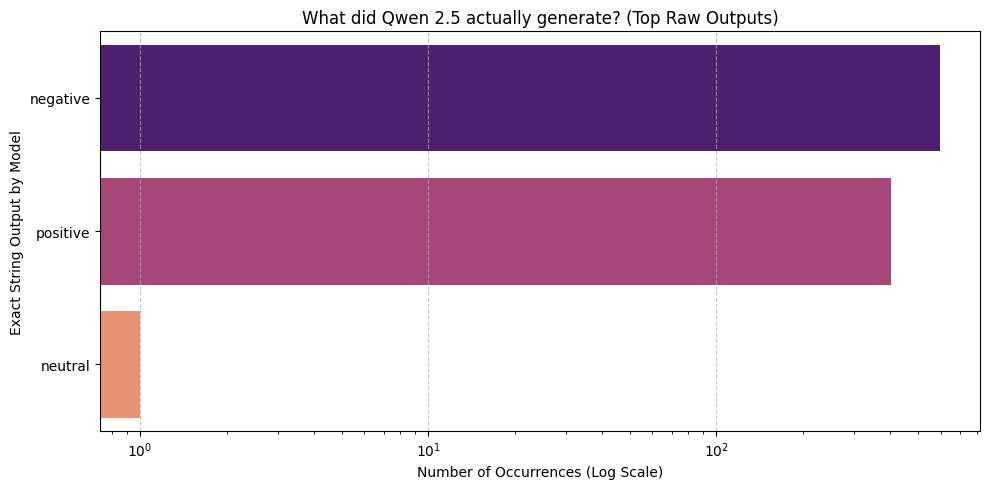


📝 All unique raw outputs generated by the model:
Raw Generated Text  Frequency
          negative        597
          positive        402
           neutral          1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Analyze the raw strings the model actually generated
output_counts = Counter(raw_responses)

# Convert to DataFrame for visualization
df_raw_outputs = pd.DataFrame(output_counts.items(), columns=["Raw Generated Text", "Frequency"])
df_raw_outputs = df_raw_outputs.sort_values(by="Frequency", ascending=False)

# Plotting the distribution of raw LLM generations
plt.figure(figsize=(10, 5))
sns.barplot(data=df_raw_outputs.head(10), x="Frequency", y="Raw Generated Text", palette="magma")
plt.title("What did Qwen 2.5 actually generate? (Top Raw Outputs)")
plt.xlabel("Number of Occurrences (Log Scale)")
plt.ylabel("Exact String Output by Model")
plt.xscale('log') # Log scale because 'positive' and 'negative' will massively dominate
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the full list of unique outputs to check for formatting anomalies
print("\n📝 All unique raw outputs generated by the model:")
print(df_raw_outputs.to_string(index=False))

## **5. Advanced Evaluation & Visual Benchmarking**

To make our architectural showdown comprehensive, we need to look beyond a single raw accuracy percentage. In this section, we will:
1. Plot a comparative bar chart for key validation metrics.
2. Generate and visualize **Confusion Matrices** for both models using heatmaps to discover where they skew (False Positives vs. False Negatives).

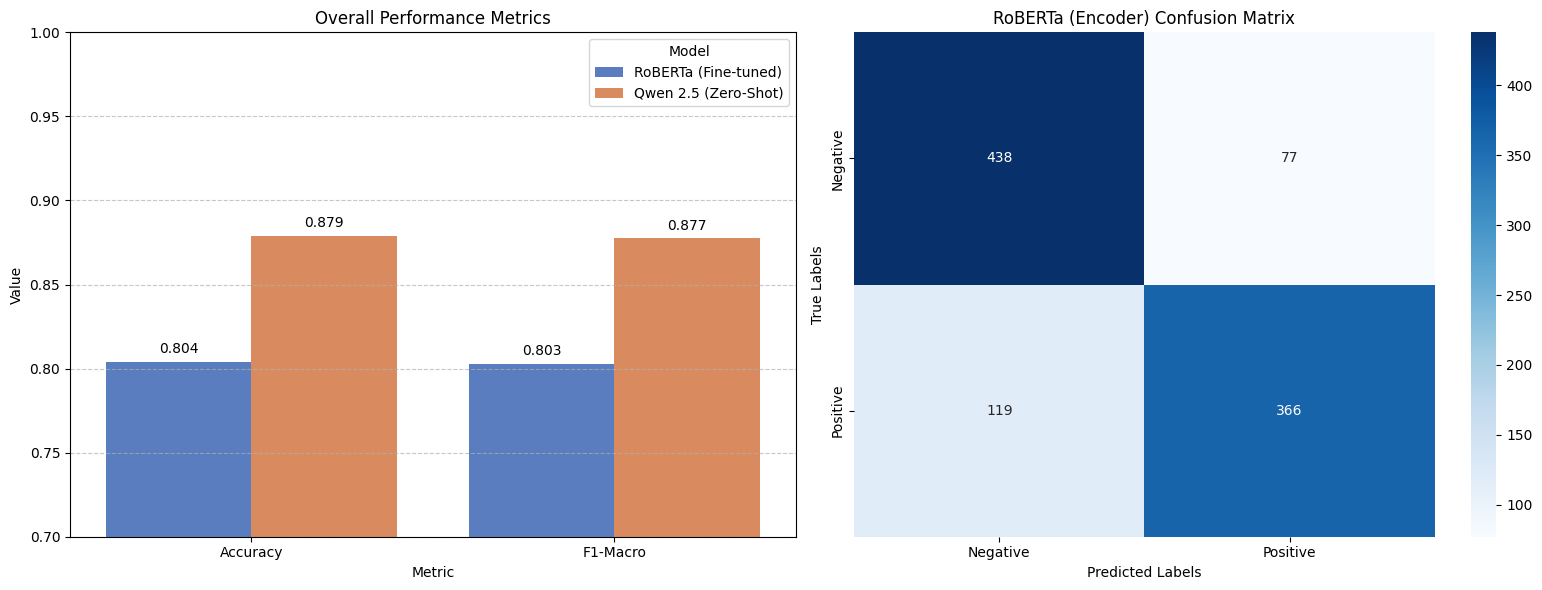

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


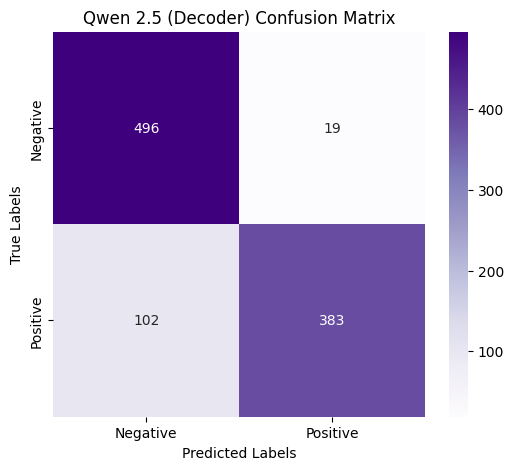

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. Extract complete metrics dictionaries
roberta_report = classification_report(true_labels, encoder_predictions, target_names=["Negative", "Positive"], output_dict=True)
qwen_report = classification_report(true_labels, decoder_predictions, target_names=["Negative", "Positive"], output_dict=True)

# Structure data for a clean Seaborn barplot
metrics_data = {
    "Model": ["RoBERTa (Fine-tuned)", "RoBERTa (Fine-tuned)", "Qwen 2.5 (Zero-Shot)", "Qwen 2.5 (Zero-Shot)"],
    "Metric": ["Accuracy", "F1-Macro", "Accuracy", "F1-Macro"],
    "Value": [
        roberta_report["accuracy"],
        roberta_report["macro avg"]["f1-score"],
        accuracy_score(true_labels, decoder_predictions),
        qwen_report["macro avg"]["f1-score"]
    ]
}
df_metrics = pd.DataFrame(metrics_data)

# 2. Plotting Performance Comparison & RoBERTa Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Subplot: Core Metric Comparison
sns.barplot(data=df_metrics, x="Metric", y="Value", hue="Model", ax=axes[0], palette="muted")
axes[0].set_title("Overall Performance Metrics")
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.005), ha='center')

# Right Subplot: RoBERTa Confusion Matrix
cm_roberta = confusion_matrix(true_labels, encoder_predictions)
sns.heatmap(cm_roberta, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
axes[1].set_title("RoBERTa (Encoder) Confusion Matrix")
axes[1].set_ylabel("True Labels")
axes[1].set_xlabel("Predicted Labels")

plt.tight_layout()
plt.show()

# 3. Plotting Qwen 2.5 Confusion Matrix
plt.figure(figsize=(6, 5))
cm_qwen = confusion_matrix(true_labels, decoder_predictions)
sns.heatmap(cm_qwen, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Qwen 2.5 (Decoder) Confusion Matrix")
plt.ylabel("True Labels")
plt.xlabel("Predicted Labels")
plt.show()